In [5]:
import os
import json
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

def _compute_mean_ci_from_runs(runs, x_key, y_key):
    """
    Align runs by the intersection of x values and compute mean ± 1.96*SE.
    runs: list of dicts loaded from seed JSONs
    """
    series = []
    for r in runs:
        x = r[x_key][:]
        y = r[y_key][:]
        if len(x) != len(y):
            L = min(len(x), len(y))
            x = x[:L]
            y = y[:L]
        series.append(dict(zip(x, y)))

    # common x values across all runs
    common_x = None
    for s in series:
        xs = set(s.keys())
        common_x = xs if common_x is None else (common_x & xs)
    if not common_x:
        raise ValueError("No common x values across runs")

    x_aligned = sorted(common_x)
    Y = np.vstack([[s[xi] for xi in x_aligned] for s in series])
    n = Y.shape[0]

    mean = Y.mean(axis=0)
    std = Y.std(axis=0, ddof=1) if n > 1 else np.zeros_like(mean)
    se = std / np.sqrt(n) if n > 0 else np.zeros_like(mean)
    z = 1.96
    lower = mean - z * se
    upper = mean + z * se
    return np.asarray(x_aligned, dtype=float), mean, lower, upper

def _palette_colors(k):
    """
    Return k distinct colors from a qualitative palette.
    """
    base = px.colors.qualitative.D3  # nice, distinct set
    if k <= len(base):
        return base[:k]
    # repeat/cycle if more algorithms than palette size
    out = []
    i = 0
    while len(out) < k:
        out.append(base[i % len(base)])
        i += 1
    return out

def plot_comarsion_problem_plotly(
    root_dir,
    x_key="generation_counter",
    y_key="best_fitness",
    title=None,
    show_runs=False,
    colors=None  # dict like {"AlgorithmA": "#1f77b4", "AlgorithmB": "red", ...}
):
    if not os.path.isdir(root_dir):
        raise ValueError(f"Not a directory: {root_dir}")
    
    alg_dirs = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
    alg_dirs = sorted(alg_dirs)
    
    if not alg_dirs:
        raise ValueError("No algorithm subfolders found.")

    # Prepare automatic colors if not provided
    auto_color_map = {}
    if colors is None:
        palette = _palette_colors(len(alg_dirs))
        auto_color_map = {alg: palette[i] for i, alg in enumerate(alg_dirs)}

    fig = go.Figure()

    for alg in alg_dirs:
        alg_path = os.path.join(root_dir, alg)
        run_files = sorted([f for f in os.listdir(alg_path) if f.endswith(".json")])
        runs = []
        for f in run_files:
            with open(os.path.join(alg_path, f), "r") as fh:
                res = json.load(fh)
                res[y_key] = np.log(res[y_key])
                runs.append(res)

        if not runs:
            continue

        x, mean, lower, upper = _compute_mean_ci_from_runs(runs, x_key, y_key)
        lower = smooth_curve(lower, window_size=3)
        upper = smooth_curve(upper, window_size=3)
        mean = smooth_curve(mean, window_size=3)

        # choose color: user-specified or automatic
        color = (colors.get(alg) if colors else auto_color_map[alg])

        if show_runs:
            for r in runs:
                xr = r[x_key]
                yr = r[y_key]
                L = min(len(xr), len(yr))
                fig.add_trace(go.Scatter(
                    x=xr[:L],
                    y=yr[:L],
                    mode="lines",
                    line=dict(width=1, dash="dot", color=color),
                    opacity=0.3,
                    name=f"{alg} (run)",
                    legendgroup=alg,
                    showlegend=False,
                    hoverinfo="skip"
                ))

        # mean curve
        fig.add_trace(go.Scatter(
            x=x,
            y=mean,
            mode="lines",
            name=alg,
            line=dict(color=color, width=2),
            legendgroup=alg,
            hovertemplate=f"{x_key.replace('_',' ').title()}: "+"%{x}<br>"+
                          f"{y_key.replace('_',' ').title()}: "+"%{y:.4f}<extra></extra>"
        ))

        # CI shaded area: use same color with low opacity (no internal/private APIs)
        fig.add_trace(go.Scatter(
            x=np.concatenate([x, x[::-1]]),
            y=np.concatenate([upper, lower[::-1]]),
            fill="toself",
            fillcolor=color,       # use the same color...
            opacity=0.2,           # ...but make it translucent
            line=dict(width=0),
            hoverinfo="skip",
            showlegend=False,
            legendgroup=alg
        ))

    fig.update_layout(
        title=title or f"Comparison: {y_key} vs {x_key} on '{root_dir.split('/')[-1]}'",
        xaxis_title=x_key.replace("_", " ").title(),
        yaxis_title=y_key.replace("_", " ").title(),
        template="plotly_white",
        hovermode="x unified"  # clean hover without dot markers
    )

    fig.show()


def smooth_curve(y, window_size=10, pad_mode="edge"):
    """
    Centered moving average with edge-aware padding.
    - window_size: use an odd integer for symmetric centering.
    - pad_mode: "edge" (replicate) or "reflect".
    """
    y = np.asarray(y, dtype=float)
    if window_size < 2 or y.size == 0:
        return y

    if window_size % 2 == 0:
        window_size += 1  # enforce odd window for proper centering

    half = window_size // 2
    y_pad = np.pad(y, (half, half), mode=pad_mode)
    kernel = np.ones(window_size, dtype=float) / window_size
    smoothed = np.convolve(y_pad, kernel, mode="valid")  # same length as y
    return smoothed


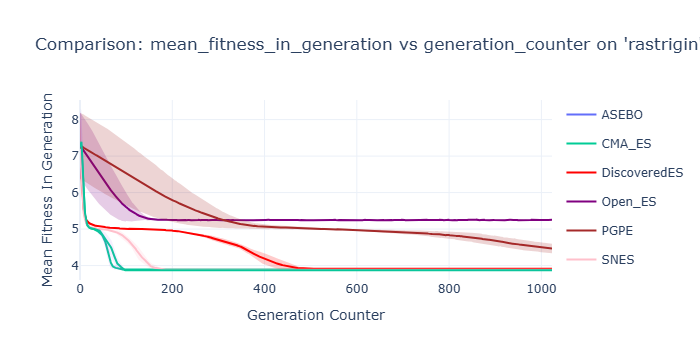

In [7]:
custom_colors = {
    "CME_ES": "blue",
    "DiscoveredES": "red",
    "EvoTF_ES": "green",
    "LearnedES": "orange",
    "Open_ES": "purple",
    "PGPE": "brown",
    "SNES": "pink",
    "SEP_CME_ES": "cyan",
    "SimpleES": "olive"
}

plot_comarsion_problem_plotly(
    "../results/BBOBProblem/rastrigin",
    x_key="generation_counter",
    y_key="mean_fitness_in_generation",
    show_runs=False,
    colors=custom_colors
)

In [3]:
import os
import json
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

EPS = 1e-12

def _load_runs_in_dir(dir_path, x_key, y_key):
    files = [f for f in os.listdir(dir_path) if f.endswith(".json")]
    runs = []
    for f in sorted(files):
        with open(os.path.join(dir_path, f), "r") as fh:
            runs.append(json.load(fh))
    runs = [r for r in runs if (x_key in r and y_key in r)]
    return runs

def _mean_curve_from_runs(runs, x_key, y_key):
    if not runs:
        return None
    x, mean, lower, upper = _compute_mean_ci_from_runs(runs, x_key, y_key)
    return x, mean, lower, upper

def _minmax_per_x(curves_dict):
    """
    curves_dict: {name: (x, y)} for one task at many algos.
    Returns x_common, {name: y_norm}
    """
    names = list(curves_dict.keys())
    if not names:
        return None, {}

    x_sets = [set(map(float, curves_dict[n][0])) for n in names]
    x_common = sorted(set.intersection(*x_sets))
    if not x_common:
        return None, {}

    y_map = {}
    for n in names:
        x, y = curves_dict[n]
        lut = dict(zip(map(float, x), y))
        y_map[n] = np.array([lut[xi] for xi in x_common], dtype=float)

    Y = np.stack([y_map[n] for n in names], axis=0)  # A x T
    ymin = Y.min(axis=0)
    ymax = Y.max(axis=0)
    span = np.maximum(ymax - ymin, EPS)
    y_norm = {n: (y_map[n] - ymin) / span for n in names}
    return np.array(x_common, dtype=float), y_norm

def _auto_colors(names, user_colors):
    if user_colors:
        return {n: user_colors.get(n, None) for n in names}
    pal = _palette_colors(len(names))
    return {n: pal[i] for i, n in enumerate(names)}

def plot_compare_auto(
    path,
    x_key="generation_counter",
    y_key="best_fitness_in_generation",
    show_runs=False,
    colors=None,
    smooth_window=10,
    normalize_specific=False  # if True, also min–max within a single specific task
):
    """
    If `path` is a specific task folder: <task>/<algo>/seed_*.json
    -> plots per-algorithm mean ± CI for that task (optionally min–max across algos).

    If `path` is a global folder with multiple subtasks: <global>/<subtask>/<algo>/seed_*.json
    -> per-subtask min–max across algos at each x, then average normalized curves across subtasks ± CI.
    """
    if not os.path.isdir(path):
        raise ValueError(f"Not a directory: {path}")

    # Heuristic: if direct children have json files under them -> specific task
    children = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
    if not children:
        raise ValueError("Folder is empty.")

    looks_like_specific = False
    for c in children:
        if c == "Archive":
            continue
        algo_dir = os.path.join(path, c)
        jfiles = [f for f in os.listdir(algo_dir) if f.endswith(".json")]
        if jfiles:
            looks_like_specific = True
            break

    if looks_like_specific:
        # SPECIFIC TASK MODE
        algos = children
        color_map = _auto_colors(algos, colors)
        curves = {}
        runs_by_algo = {}

        for algo in algos:
            algo_dir = os.path.join(path, algo)
            runs = _load_runs_in_dir(algo_dir, x_key, y_key)
            if not runs:
                continue
            x, mean, lower, upper = _mean_curve_from_runs(runs, x_key, y_key)
            if smooth_window and smooth_window > 1:
                mean = smooth_curve(mean, smooth_window)
                lower = smooth_curve(lower, smooth_window)
                upper = smooth_curve(upper, smooth_window)
            curves[algo] = (x, mean, lower, upper)
            runs_by_algo[algo] = runs

        if not curves:
            raise ValueError("No runs found in specific-task folder.")

        if normalize_specific:
            # min–max across algos per x on the mean curves
            x_common, norm_means = _minmax_per_x({k: (v[0], v[1]) for k, v in curves.items()})
            if x_common is None:
                raise ValueError("Could not align x across algorithms for normalization.")
        fig = go.Figure()
        for algo, (x, mean, lower, upper) in curves.items():
            color = color_map.get(algo)
            if normalize_specific:
                # rebuild lower/upper by applying same affine transform per x
                # lower/upper bands are mostly for visual context; we normalize the mean strictly.
                x = x_common
                mean = norm_means[algo]
                # fallback: no CI after normalization (we did not normalize variance)
                lower = None
                upper = None

            if show_runs:
                for r in runs_by_algo[algo]:
                    xr = r[x_key]
                    yr = r[y_key]
                    L = min(len(xr), len(yr))
                    go_trace = go.Scatter(
                        x=xr[:L],
                        y=yr[:L],
                        mode="lines",
                        line=dict(width=1, dash="dot", color=color),
                        opacity=0.25,
                        name=f"{algo} (run)",
                        legendgroup=algo,
                        showlegend=False,
                        hoverinfo="skip"
                    )
                    fig.add_trace(go_trace)

            fig.add_trace(go.Scatter(
                x=x, y=mean, mode="lines", name=algo,
                line=dict(color=color, width=2),
                legendgroup=algo,
                hovertemplate=f"{x_key.replace('_',' ').title()}: "+"%{x}<br>"+
                              ("Norm " if normalize_specific else "") +
                              f"{y_key.replace('_',' ').title()}: "+"%{y:.4f}<extra></extra>"
            ))
            if lower is not None and upper is not None:
                fig.add_trace(go.Scatter(
                    x=np.concatenate([x, x[::-1]]),
                    y=np.concatenate([upper, lower[::-1]]),
                    fill="toself",
                    fillcolor=color,
                    opacity=0.2,
                    line=dict(width=0),
                    hoverinfo="skip",
                    showlegend=False,
                    legendgroup=algo
                ))

        fig.update_layout(
            title=f"{'Normalized ' if normalize_specific else ''}Comparison on '{os.path.basename(path)}'",
            xaxis_title=x_key.replace("_", " ").title(),
            yaxis_title=("Normalized " if normalize_specific else "") + y_key.replace("_", " ").title(),
            template="plotly_white",
            hovermode="x unified"
        )
        fig.show()
        return

    # GLOBAL MODE: children are subtasks
    subtasks = children

    # collect union of algos
    all_algos = set()
    for st in subtasks:
        st_path = os.path.join(path, st)
        algs = [d for d in os.listdir(st_path) if os.path.isdir(os.path.join(st_path, d))]
        all_algos.update(algs)
    all_algos = sorted(all_algos)
    if not all_algos:
        raise ValueError("No algorithm folders under subtasks.")

    color_map = _auto_colors(all_algos, colors)

    # per-subtask normalization
    per_subtask_norm = {}  # st -> {algo: (x_common, y_norm)}
    for st in subtasks:
        st_path = os.path.join(path, st)
        curves = {}
        for algo in all_algos:
            algo_dir = os.path.join(st_path, algo)
            if not os.path.isdir(algo_dir):
                continue
            runs = _load_runs_in_dir(algo_dir, x_key, y_key)
            if not runs:
                continue
            x, mean, _, _ = _mean_curve_from_runs(runs, x_key, y_key)
            curves[algo] = (x, mean)
        if not curves:
            continue
        x_common, y_norm = _minmax_per_x(curves)
        if x_common is None:
            continue
        per_subtask_norm[st] = {a: (x_common, y_norm[a]) for a in y_norm.keys()}

    if not per_subtask_norm:
        raise ValueError("No valid normalized curves found across subtasks.")

    fig = go.Figure()
    for algo in all_algos:
        # gather this algo across all subtasks where it exists
        series = []
        x_common = None
        for st, d in per_subtask_norm.items():
            if algo not in d:
                continue
            xs, ys = d[algo]
            xs = np.asarray(xs, dtype=float)
            ys = np.asarray(ys, dtype=float)
            x_common = set(xs) if x_common is None else (x_common & set(xs))
            series.append((xs, ys))
        if not series or not x_common:
            continue
        x_common = np.array(sorted(x_common), dtype=float)

        Y = []
        for xs, ys in series:
            lut = {float(xx): float(yy) for xx, yy in zip(xs, ys)}
            Y.append([lut[xi] for xi in x_common])
        Y = np.array(Y, dtype=float)  # subtasks x T

        mean = Y.mean(axis=0)
        std = Y.std(axis=0, ddof=1) if Y.shape[0] > 1 else np.zeros_like(mean)
        se = std / np.sqrt(max(1, Y.shape[0]))
        z = 1.96
        lower = mean - z * se
        upper = mean + z * se

        if smooth_window and smooth_window > 1:
            mean = smooth_curve(mean, smooth_window)
            lower = smooth_curve(lower, smooth_window)
            upper = smooth_curve(upper, smooth_window)

        color = color_map.get(algo) or px.colors.qualitative.D3[0]
        fig.add_trace(go.Scatter(
            x=x_common, y=mean, mode="lines", name=algo,
            line=dict(color=color, width=2),
            hovertemplate=f"{x_key.replace('_',' ').title()}: "+"%{x}<br>"+
                          "Avg Norm Perf: "+"%{y:.3f}<extra></extra>"
        ))
        fig.add_trace(go.Scatter(
            x=np.concatenate([x_common, x_common[::-1]]),
            y=np.concatenate([upper, lower[::-1]]),
            fill="toself",
            fillcolor=color,
            opacity=0.2,
            line=dict(width=0),
            hoverinfo="skip",
            showlegend=False
        ))

    fig.update_layout(
        title=f"Average min–max normalized {y_key} over subtasks in '{os.path.basename(path)}'",
        xaxis_title=x_key.replace("_", " ").title(),
        yaxis_title="Average normalized performance (lower is better)",
        template="plotly_white",
        hovermode="x unified"
    )
    fig.show()


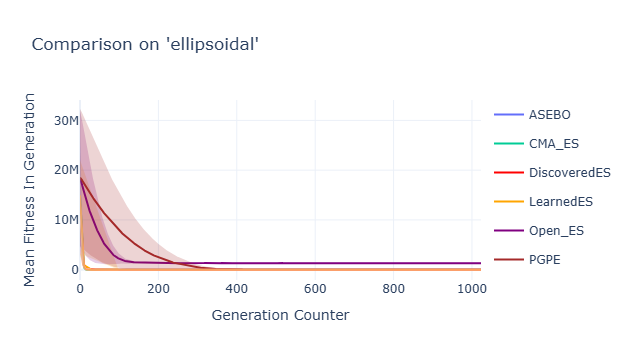

In [7]:
custom_colors = {
    "CME_ES": "blue",
    "DiscoveredES": "red",
    "EvoTF_ES": "green",
    "LearnedES": "orange",
    "Open_ES": "purple",
    "PGPE": "brown",
    "SNES": "pink",
    "SEP_CME_ES": "cyan",
    "SimpleES": "olive"
}


plot_compare_auto(
    "../results/BBOBProblem/ellipsoidal",
    x_key="generation_counter",
    y_key="mean_fitness_in_generation",
    normalize_specific=False,
    show_runs=False,
    colors=custom_colors
)
